# Plant Disease Classification Runtime Analysis


In [15]:
import os
from email.mime import image
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torchvision.transforms.v2 as T
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize
from torch import nn
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from src.dataset import PlantDiseaseDataset
from src.metrics import MetricTracker
from src.models import PlantDiseaseModel
from src.utils import load_config, set_seed

plt.style.use("seaborn-v0_8-muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")

In [2]:
import json

label_map_path = os.path.join(DATA_DIR, "label_map.json")
with open(label_map_path) as f:
    label_map = json.load(f)

In [4]:
image_size = 384

transforms = T.Compose(
    [
        T.Resize((image_size, image_size), antialias=True),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


val_dataset = PlantDiseaseDataset(
    VAL_DIR,
    label_map=label_map,
    transform=transforms,
)

In [5]:
batch_size = 16
pin_memory = False

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
)

In [6]:
backbone_name = "convnextv2_tiny.fcmae_ft_in22k_in1k_384"
checkpoint_path = "checkpoints/cn_best.pt"
mixed_precision = False
drop_path = 0.2
drop_rate = 0.2


class PlantDiseaseModel(nn.Module):
    def __init__(self, config, num_classes):
        super().__init__()
        self.backbone_name = config

        self.model = timm.create_model(
            self.backbone_name,
            pretrained=True,
            num_classes=num_classes,
            drop_rate=drop_rate,
            drop_path_rate=drop_path,
        )

    def forward(self, x):
        return self.model(x)


model = PlantDiseaseModel(backbone_name, num_classes=39)
checkpoint = torch.load(checkpoint_path, map_location=device)
state_dict = checkpoint.get("state_dict", checkpoint)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [7]:
model.eval()
scripted_model = torch.jit.script(model)
scripted_model.save("convnext_scripted.pt")

In [16]:
model = torch.jit.load("checkpoints/convnext_scripted.pt").to(device)

In [ ]:
from src.infer import get_tta_transforms
from sklearn.metrics import accuracy_score, average_precision_score


def evaluate(model, val_loader, device=None, use_tta=False, image_size=384):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    if use_tta:
        tta_transforms = get_tta_transforms(image_size)

    all_probs = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            if use_tta:
                tta_batches = []

                for transform in tta_transforms:
                    augmented = torch.stack([transform(img.cpu()) for img in images])
                    tta_batches.append(augmented)

                tta_batches = torch.stack(tta_batches).to(device)

                outputs = []
                for tta_batch in tta_batches:
                    out = model(tta_batch)  # [batch, num_classes]
                    outputs.append(out)

                outputs = torch.stack(outputs).mean(dim=0)

            else:
                outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    preds = np.argmax(all_probs, axis=1)
    acc = accuracy_score(all_labels, preds)

    num_classes = all_probs.shape[1]
    y_true_bin = np.zeros((len(all_labels), num_classes))
    y_true_bin[np.arange(len(all_labels)), all_labels] = 1

    per_class_ap = []
    for i in range(num_classes):
        if y_true_bin[:, i].sum() > 0:
            ap = average_precision_score(y_true_bin[:, i], all_probs[:, i])
            per_class_ap.append(ap)

    mAP = np.mean(per_class_ap)

    return acc, mAP, all_probs, all_labels


def plot_confusion_matrix(preds, all_labels, label_map):
    idx_to_disease = {v: k for k, v in label_map.items()}
    cm = confusion_matrix(all_labels, preds)
    disease_names = [idx_to_disease[i] for i in range(len(label_map))]

    plt.figure(figsize=(20, 16))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=disease_names,
        yticklabels=disease_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
effnet = torch.jit.load("effnet_scripted.pt").to(device)

In [ ]:
acc, mAP, all_probs, all_labels = evaluate(effnet, val_loader, device=device)

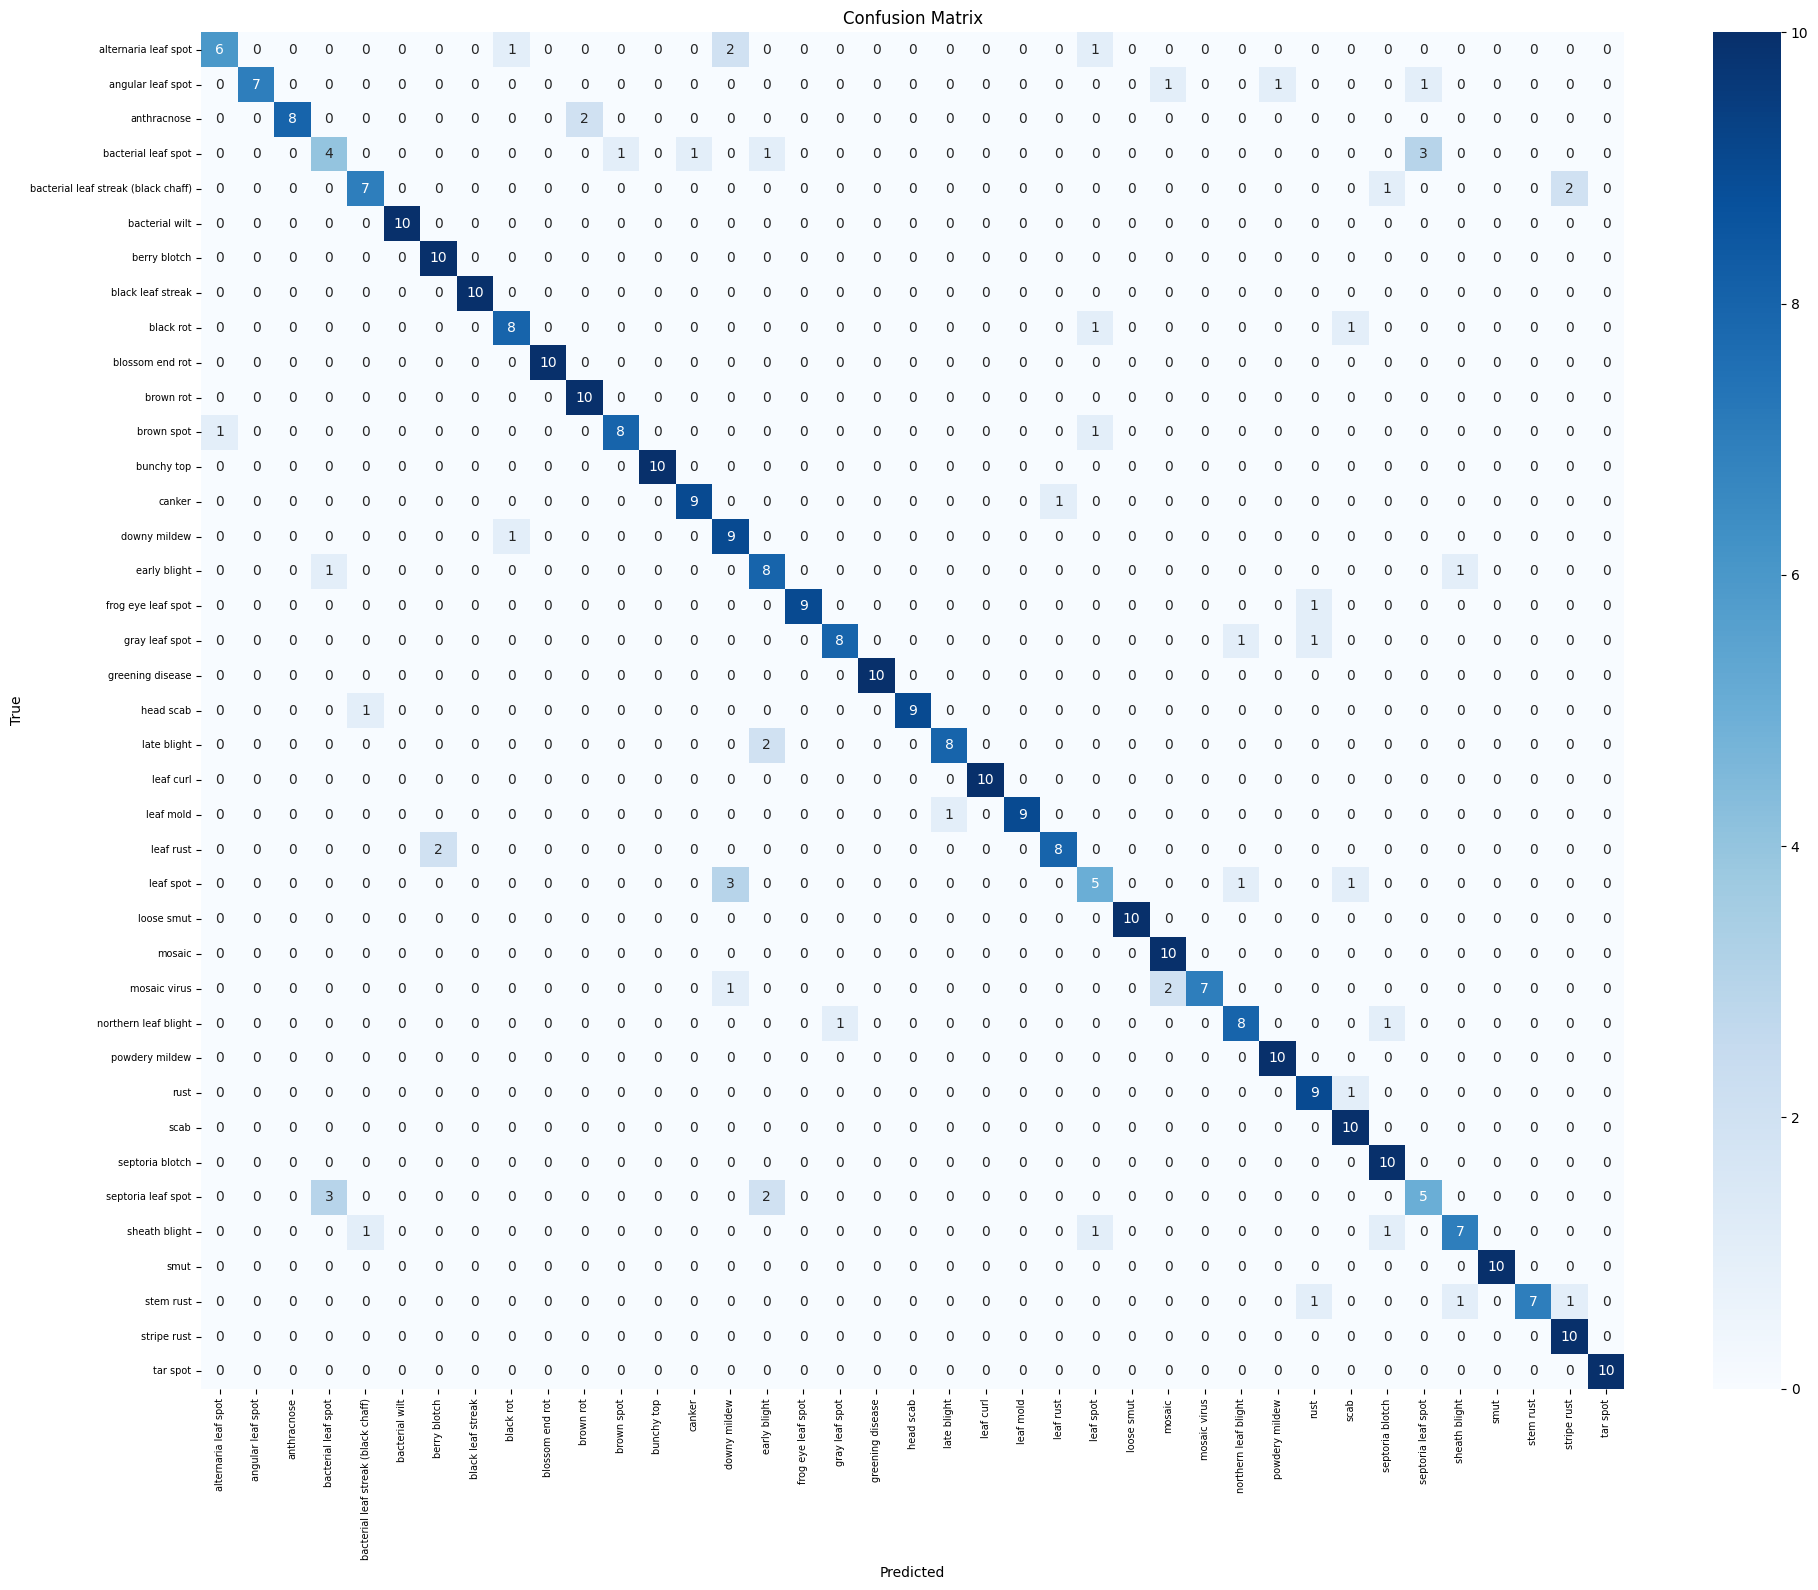

In [ ]:
plot_confusion_matrix(all_probs, all_labels, label_map)